# Loading Dataset
# NIFTY 50 / Sensex dataset.

In [53]:
import kagglehub

path = kagglehub.dataset_download("rockyt07/stock-market-sensex-nifty-all-time-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stock-market-sensex-nifty-all-time-dataset' dataset.
Path to dataset files: /kaggle/input/stock-market-sensex-nifty-all-time-dataset


# Importing essential libraries for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn).

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Loading the NIFTY 50 CSV file into a pandas DataFrame for analysis.

In [55]:

df = pd.read_csv('/kaggle/input/stock-market-sensex-nifty-all-time-dataset/NIFTY_50.csv')

# Checking column data types, non-null counts, and general memory usage.

In [56]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4452 non-null   object 
 1   Adj Close       4452 non-null   float64
 2   Close           4452 non-null   float64
 3   High            4452 non-null   float64
 4   Low             4452 non-null   float64
 5   Open            4452 non-null   float64
 6   Volume          4452 non-null   int64  
 7   SMA_20          4433 non-null   float64
 8   SMA_50          4403 non-null   float64
 9   EMA_12          4452 non-null   float64
 10  EMA_26          4452 non-null   float64
 11  MACD            4452 non-null   float64
 12  Signal_Line     4452 non-null   float64
 13  RSI_14          4439 non-null   float64
 14  BB_Mid          4433 non-null   float64
 15  BB_Upper        4433 non-null   float64
 16  BB_Lower        4433 non-null   float64
 17  Daily_Return_%  4451 non-null   f

In [57]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,MACD,Signal_Line,RSI_14,BB_Mid,BB_Upper,BB_Lower,Daily_Return_%
0,2007-09-17,4494.649902,4494.649902,4549.049805,4482.850098,4518.450195,0,NaN,NaN,4494.649902,4494.649902,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,2007-09-18,4546.200195,4546.200195,4551.799805,4481.549805,4494.100098,0,NaN,NaN,4502.580717,4498.468443,4.112274,0.822455,NaN,NaN,NaN,NaN,1.146926
2,2007-09-19,4732.350098,4732.350098,4739.000000,4550.250000,4550.250000,0,NaN,NaN,4537.929852,4515.793010,22.136843,5.085332,NaN,NaN,NaN,NaN,4.094626
3,2007-09-20,4747.549805,4747.549805,4760.850098,4721.149902,4734.850098,0,NaN,NaN,4570.179076,4532.960180,37.218896,11.512045,NaN,NaN,NaN,NaN,0.321187
4,2007-09-21,4837.549805,4837.549805,4855.700195,4733.700195,4752.950195,0,NaN,NaN,4611.313034,4555.522374,55.790660,20.367768,NaN,NaN,NaN,NaN,1.895715


In [58]:
print(df.isnull().sum())

Date               0
Adj Close          0
Close              0
High               0
Low                0
Open               0
Volume             0
SMA_20            19
SMA_50            49
EMA_12             0
EMA_26             0
MACD               0
Signal_Line        0
RSI_14            13
BB_Mid            19
BB_Upper          19
BB_Lower          19
Daily_Return_%     1
dtype: int64


# Removing any rows with missing values to ensure statistical tests and models run correctly.

In [59]:
df = df.dropna()

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4403 entries, 49 to 4451
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4403 non-null   object 
 1   Adj Close       4403 non-null   float64
 2   Close           4403 non-null   float64
 3   High            4403 non-null   float64
 4   Low             4403 non-null   float64
 5   Open            4403 non-null   float64
 6   Volume          4403 non-null   int64  
 7   SMA_20          4403 non-null   float64
 8   SMA_50          4403 non-null   float64
 9   EMA_12          4403 non-null   float64
 10  EMA_26          4403 non-null   float64
 11  MACD            4403 non-null   float64
 12  Signal_Line     4403 non-null   float64
 13  RSI_14          4403 non-null   float64
 14  BB_Mid          4403 non-null   float64
 15  BB_Upper        4403 non-null   float64
 16  BB_Lower        4403 non-null   float64
 17  Daily_Return_%  4403 non-null   float

In [61]:
df['Date'] = pd.to_datetime(df['Date'])

# Converting the 'Date' column to datetime objects and setting it as the DataFrame index.


In [62]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [63]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,MACD,Signal_Line,RSI_14,BB_Mid,BB_Upper,BB_Lower,Daily_Return_%
Date,,,,,,,,,,,,,,,,,
2007-11-27,5698.149902,5698.149902,5743.549805,5655.600098,5729.250000,0,5777.994995,5440.556992,5712.206380,5654.110562,58.095818,102.547861,46.179454,5777.994995,6040.365142,5515.624848,-0.585346
2007-11-28,5617.549805,5617.549805,5749.950195,5595.500000,5699.549805,0,5765.434985,5463.014990,5697.643830,5651.402358,46.241473,91.286583,43.315473,5765.434985,6033.500986,5497.368985,-1.414496
2007-11-29,5634.600098,5634.600098,5725.000000,5612.100098,5617.799805,0,5752.132495,5484.782988,5687.944794,5650.157746,37.787049,80.586676,47.249500,5752.132495,6018.344768,5485.920223,0.303518
2007-11-30,5762.750000,5762.750000,5782.549805,5632.649902,5633.899902,0,5746.947485,5505.390986,5699.453288,5658.497913,40.955375,72.660416,56.005439,5746.947485,6007.769722,5486.125249,2.274339
2007-12-03,5865.000000,5865.000000,5878.799805,5754.600098,5765.450195,0,5743.577490,5527.739990,5724.922013,5673.794364,51.127649,68.353863,56.857516,5743.577490,5995.914272,5491.240708,1.774326


# **TREND ANALYSIS**

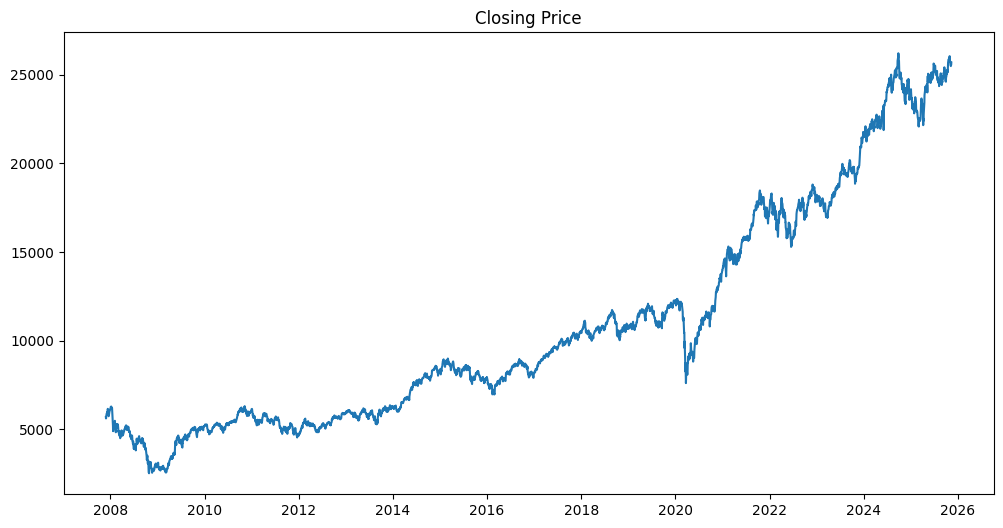

In [64]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'])
plt.title('Closing Price')
plt.show()

# Plotting Closing Price alongside Bollinger Bands and the 50-day Simple Moving Average (SMA).


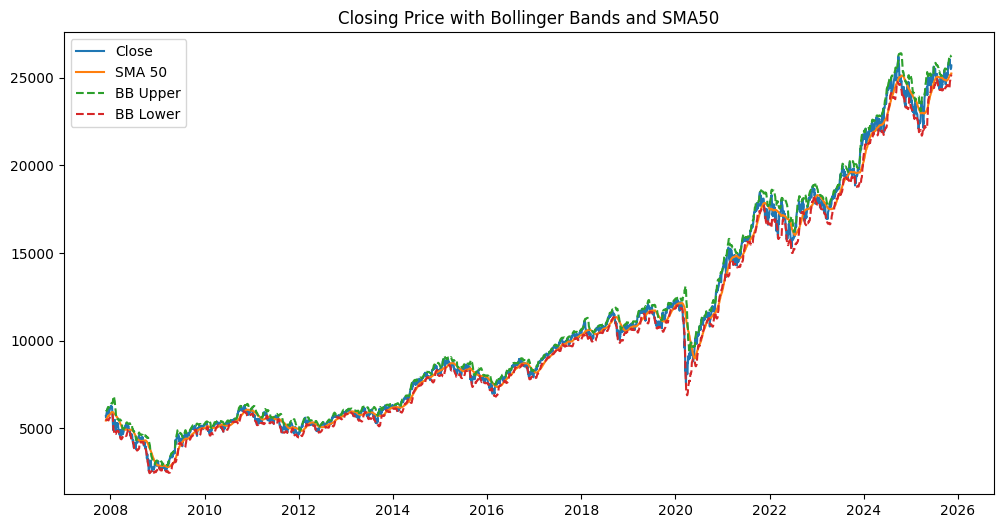

In [65]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['SMA_50'], label='SMA 50')
plt.plot(df.index, df['BB_Upper'], label='BB Upper', linestyle='--')
plt.plot(df.index, df['BB_Lower'], label='BB Lower', linestyle='--')
plt.title('Closing Price with Bollinger Bands and SMA50')
plt.legend()
plt.show()

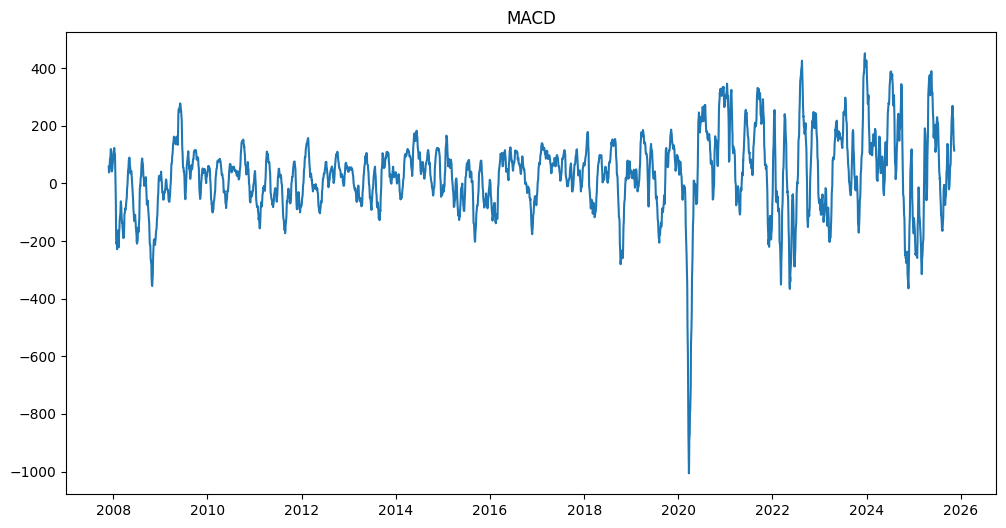

In [66]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['MACD'])
plt.title("MACD")
plt.show()

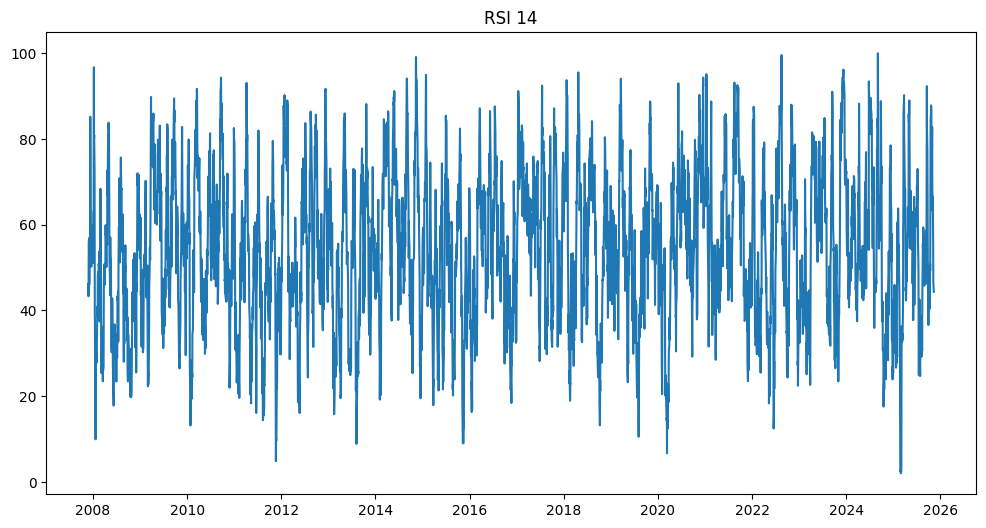

In [67]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['RSI_14'])
plt.title("RSI 14")
plt.show()

<Axes: xlabel='Volume', ylabel='Count'>

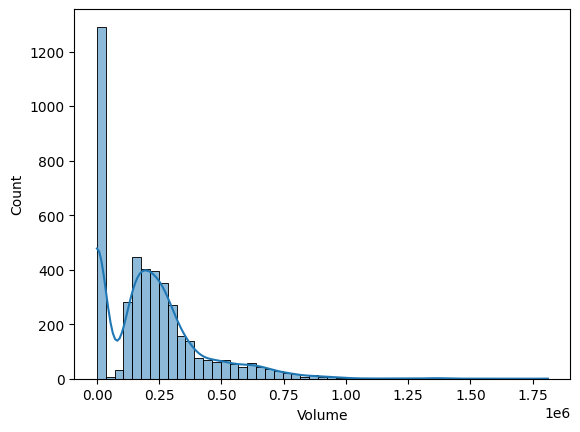

In [68]:
sns.histplot(df['Volume'], kde = True)

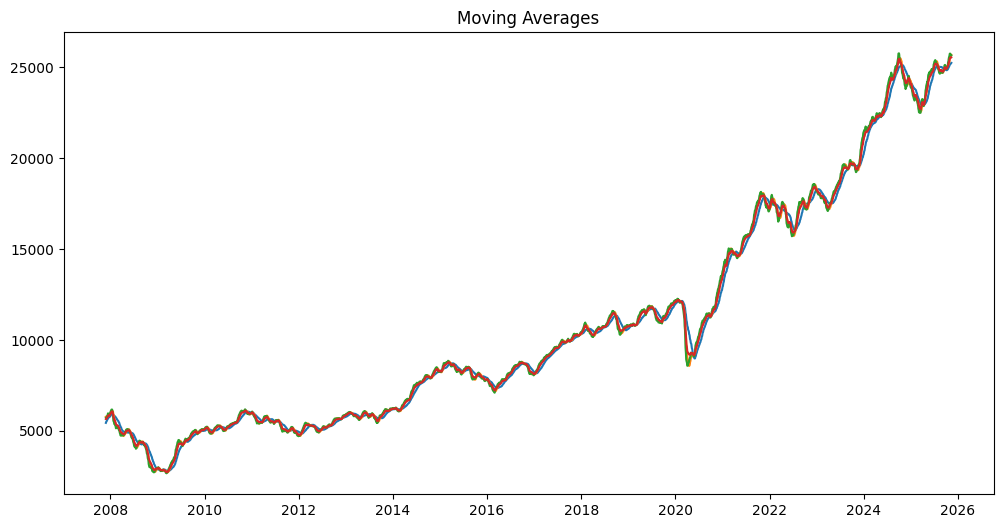

In [69]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['SMA_50'])
plt.plot(df.index, df['SMA_20'])
plt.plot(df.index, df['EMA_12'])
plt.plot(df.index, df['EMA_26'])
plt.title("Moving Averages")
plt.show()

<Axes: xlabel='Daily_Return_%', ylabel='Count'>

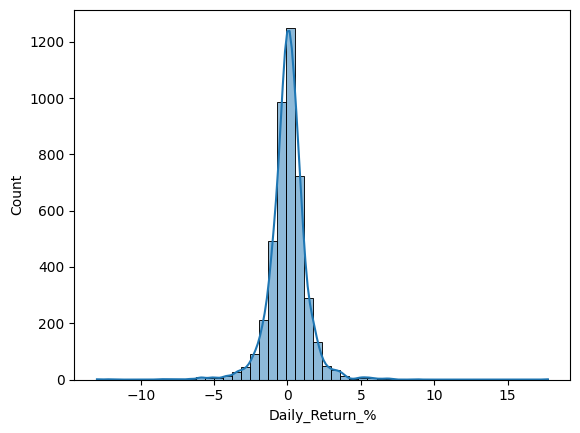

In [70]:
sns.histplot(df['Daily_Return_%'],bins = 50, kde=True)

<Axes: >

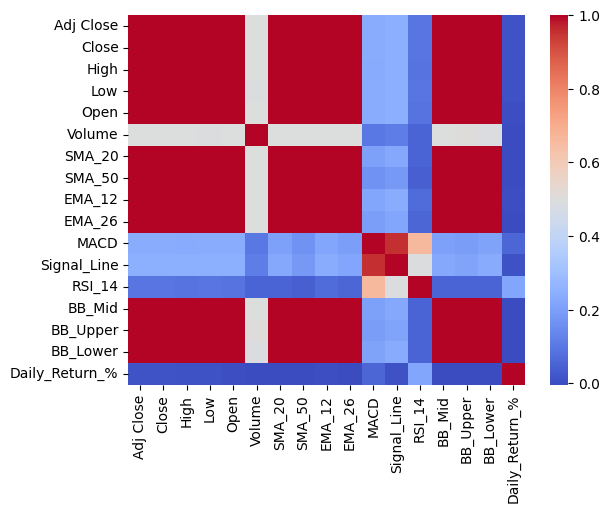

In [71]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm',annot=False)

In [72]:
!pip install statsmodels

# **SEASONALITY DETECTION**

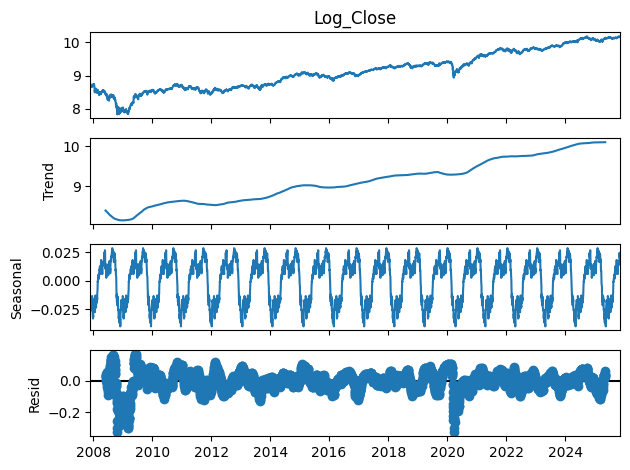

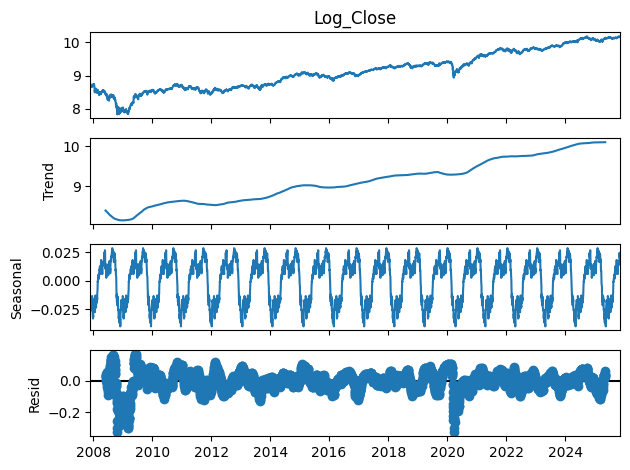

In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose

df2 = df[['Close']].copy()
df2['Log_Close'] = np.log(df2['Close'])

result = seasonal_decompose(
    df2['Log_Close'],
    model='additive',
    period=252
)

result.plot()

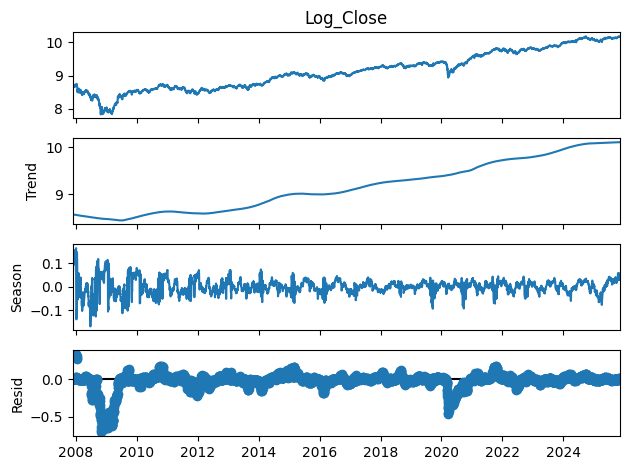

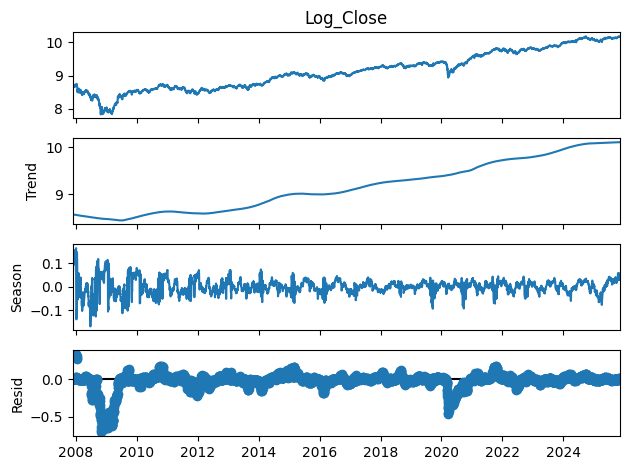

In [74]:
# multiplicative model solves problem(Constant seasonal amplitude despite high price growth) with the additive one
# Large 2020 residual handled better with STL

from statsmodels.tsa.seasonal import STL

stl = STL(df2['Log_Close'], period=252, robust=True)
result_stl = stl.fit()
result_stl.plot()

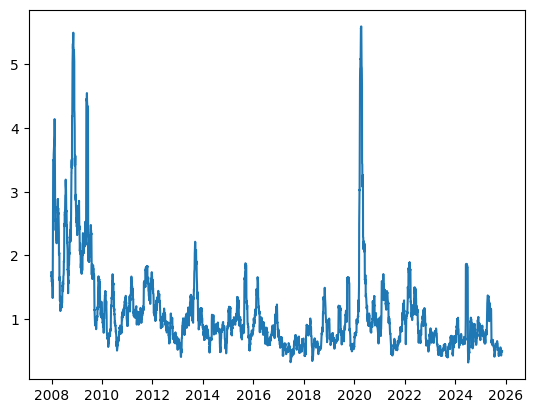

In [75]:
rolling_std = df['Daily_Return_%'].rolling(20).std() # volatile

plt.plot(df.index, rolling_std) #Periods of high rolling standard deviation indicate increased market uncertainty.

# Using the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary.


In [76]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    adf_result = adfuller(series.dropna())
    print("-- ADF Test --")
    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"p-value       : {adf_result[1]:.4f}")
    print(f"Conclusion    : {'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")

check_stationarity(df['Close'])

-- ADF Test --
ADF Statistic : 1.2678
p-value       : 0.9964
Conclusion    : Non-Stationary


In [77]:
# First difference to make stationary
df['Close_diff'] = df['Close'].diff() #each row now holds "how much did the price change from yesterday?",( first differencing)
check_stationarity(df['Close_diff'])



-- ADF Test --
ADF Statistic : -15.3616
p-value       : 0.0000
Conclusion    : Stationary


In [78]:
d = 1

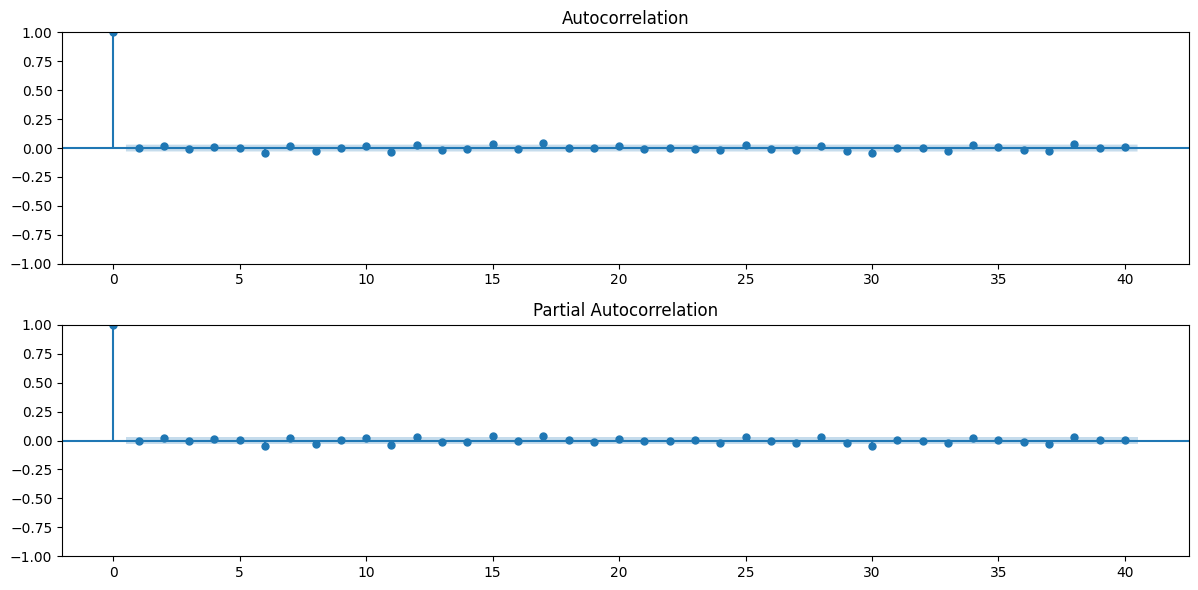

In [79]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(df['Close_diff'].dropna(),  lags=40, ax=axes[0])  # q
plot_pacf(df['Close_diff'].dropna(), lags=40, ax=axes[1])  # p

plt.tight_layout()
plt.show()

In [80]:
p = 0
q = 0
# it is a pure white noise after differencing No lagged values add any extra information The differenced series has no exploitable autocorrelation
from statsmodels.tsa.arima.model import ARIMA

p, d, q = (0, 1, 0)

model = ARIMA(df['Close'], order=(p, d, q))
arima_result = model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4403
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -27285.913
Date:                Sat, 13 Jun 2026   AIC                          54573.826
Time:                        12:01:53   BIC                          54580.215
Sample:                             0   HQIC                         54576.080
                               - 4403                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.417e+04    115.017    123.207      0.000    1.39e+04    1.44e+04
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             26413.98
Prob(Q):                              0.93   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# Fitting an ARIMA(0,1,0) model (Random Walk) to forecast the next 30 trading days.


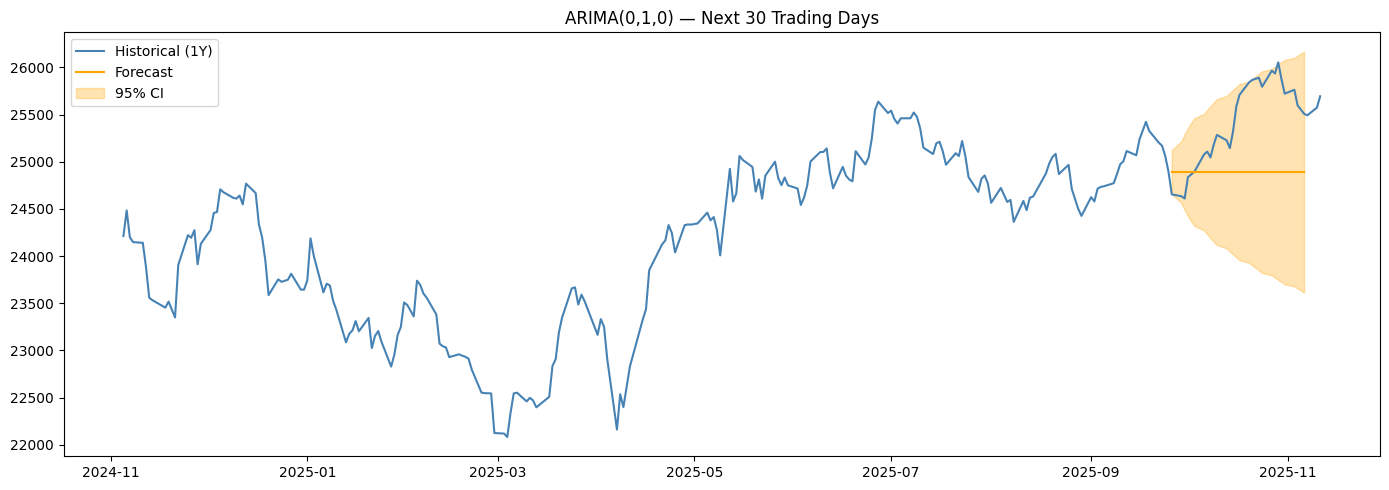

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

last_date    = train.index[-1]
future_index = pd.bdate_range(start=last_date, periods=31)[1:]

forecast_mean.index = future_index
forecast_ci         = forecast.conf_int()
forecast_ci.index   = future_index

plt.figure(figsize=(14, 5))
plt.plot(df['Close'][-252:], label='Historical (1Y)', color='steelblue')
plt.plot(forecast_mean,      label='Forecast',        color='orange')
plt.fill_between(future_index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.3, color='orange', label='95% CI')
plt.title('ARIMA(0,1,0) — Next 30 Trading Days')
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/test split
train = df['Close'][:-30]
test  = df['Close'][-30:]

model_eval = ARIMA(train, order=(0, 1, 0)).fit()
predictions = model_eval.forecast(steps=30)

mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 594.54
RMSE : 686.42
MAPE : 2.32%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p